# 02. Carga académica disponible

**Fuente:** `data/raw/cargaacademicadisponible.csv`  
**Salida:** `data/processed/carga_academica_disponible.csv`

Asignaturas dictadas por cada docente en cada periodo academico (carga horaria, materia, unidad). Aporta variables de trayectoria y dedicacion docente.

In [34]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))
import pandas as pd
import _preprocesamiento_comun as pc

pd.set_option('display.max_columns', 100)

## 1. Carga de datos crudos

In [35]:
df = pc.leer_csv('cargaacademicadisponible.csv', low_memory=False)
df.head()

Leido cargaacademicadisponible.csv con encoding=utf-8-sig -> 43701 filas, 45 columnas


,IDCPLCAMBIOSCURSO,HORASTEORICAS,HORASPRACTICAS,HORASEVALUACION,IDPERSONA,NUMEROIDENTIFICACION,TIPOIDENTIFICACION,NOMDOCENTE,EMAIL,EMAILALTERNO,IDCURSO,PORC,ANIO,TERM,NUMREGISTRADOS,PARALELO,CAPACIDAD,CUPOPLANIFICADO,IDUNIDAD,CODUNIDAD,NOMBREUNIDAD,IDUNIDADCARGA,IDMATERIA,CODIGOMATERIA,NOMMATERIA,NUMCREDITOS,TIPOCURSO,NUMHORASTEORICAS,NUMHORASPRACTICAS,IDTIPOACTIVIDAD,IDPERIODO,FECHAAPROBPLANIF,FECHAINICIOREGIST,OBSERVACION,APROBADO,NUMHORASCA,DEDICDOCENTETEORICA,DEDICPLANIFITEORICA,DEDICDOCENTEPRACTICA,VALOREVALUACION,VALORNUMEXAM,FECHA_INICIO,FECHA_FIN,TIPOPROFESOR,TOTALHORAS
0,65429,2,1,0,1298,0911582120,CED,LAVAYEN CARDOSO LUIS ENRIQUE,llavayen@espol.edu.ec,e_lavayen@hotmail.com,171804,25.0,2024,1S,0,101,1,17,15266,ESPL,ESCUELA SUPERIOR POLITECNICA DEL LITORAL,NaN,7879,IDIT3003,INGLÉS TÉCNICO I,0.0,G,2,1,17,598,2026-08-28,2026-08-28,DOCENCIA,S,3,0,0,0,0,2,2024-06-24-00.00.00.000000,2024-06-30-00.00.00.000000,C,0.38
1,89609,3,1,0,4714,0923667927,CED,AVENDAÑO SUDARIO ALLAN ROBERTO,aavendan@espol.edu.ec,aavendan@gmail.com,182090,100.0,2026,1S,30,101,30,35,15004,FIEC,Facultad de Ingeniería en Electricidad y Compu...,NaN,6822,SOFG1006,DESARROLLO DE APLICACIONES WEB Y MÓVILES,0.0,G,3,1,17,605,2026-08-28,2026-08-28,DOCENCIA,S,4,0,0,0,0,6,2026-05-13-00.00.00.000000,2026-05-15-00.00.00.000000,T,0.62
2,89613,3,1,0,4714,0923667927,CED,AVENDAÑO SUDARIO ALLAN ROBERTO,aavendan@espol.edu.ec,aavendan@gmail.com,182110,100.0,2026,1S,22,103,30,35,15004,FIEC,Facultad de Ingeniería en Electricidad y Compu...,NaN,6822,SOFG1006,DESARROLLO DE APLICACIONES WEB Y MÓVILES,0.0,G,3,1,17,605,2026-08-28,2026-08-28,DOCENCIA,S,4,0,0,0,0,6,2026-05-13-00.00.00.000000,2026-05-15-00.00.00.000000,T,0.62
3,65425,2,1,0,1298,0911582120,CED,LAVAYEN CARDOSO LUIS ENRIQUE,llavayen@espol.edu.ec,e_lavayen@hotmail.com,171803,25.0,2024,1S,15,1,16,16,15266,ESPL,ESCUELA SUPERIOR POLITECNICA DEL LITORAL,NaN,7879,IDIT3003,INGLÉS TÉCNICO I,0.0,P,2,1,17,598,2026-08-28,2026-08-28,DOCENCIA,S,3,0,0,0,0,2,2024-06-24-00.00.00.000000,2024-06-30-00.00.00.000000,C,0.77
4,16805,3,0,0,59234,0928567783,CED,VALENCIA ERAZO LUZ MARÍA,lmvalenc@espol.edu.ec,lzmvalencia@gmail.com,138539,15.0,2020,1S,14,1,20,20,15300,FCV,Facultad de Ciencias de la Vida,NaN,6955,NUTG2036,NUTRICIÓN EN EL CICLO DE LA VIDA I,0.0,P,3,0,17,574,2026-08-28,2026-08-28,DOCENCIA,S,3,0,0,0,0,6,2020-05-25-00.00.00.000000,2020-06-05-00.00.00.000000,C,1.34


## 2. Exploración inicial

In [36]:
pc.resumen(df, 'carga_academica_disponible')

--- Resumen carga_academica_disponible ---
Dimensiones: 43701 filas x 45 columnas
Filas duplicadas: 0
Columnas con nulos (%):
IDUNIDADCARGA    99.8
APROBADO          0.9
EMAIL             0.2
EMAILALTERNO      0.2
dtype: float64


In [37]:
df.dtypes

IDCPLCAMBIOSCURSO         int64
HORASTEORICAS             int64
HORASPRACTICAS            int64
HORASEVALUACION           int64
IDPERSONA                 int64
NUMEROIDENTIFICACION     object
TIPOIDENTIFICACION       object
NOMDOCENTE               object
EMAIL                    object
EMAILALTERNO             object
IDCURSO                   int64
PORC                    float64
ANIO                      int64
TERM                     object
NUMREGISTRADOS            int64
PARALELO                  int64
CAPACIDAD                 int64
CUPOPLANIFICADO           int64
IDUNIDAD                  int64
CODUNIDAD                object
NOMBREUNIDAD             object
IDUNIDADCARGA           float64
IDMATERIA                 int64
CODIGOMATERIA            object
NOMMATERIA               object
NUMCREDITOS             float64
TIPOCURSO                object
NUMHORASTEORICAS          int64
NUMHORASPRACTICAS         int64
IDTIPOACTIVIDAD           int64
IDPERIODO                 int64
FECHAAPR

## 3. Limpieza

In [38]:
df = pc.limpiar_strings(df)
df = pc.quitar_columnas_vacias(df, umbral=0.001)
df = pc.quitar_columnas_constantes(df)

Columnas eliminadas por tener >= 0% de nulos: ['EMAIL', 'EMAILALTERNO', 'IDUNIDADCARGA', 'APROBADO']
Columnas eliminadas por ser constantes: ['HORASEVALUACION', 'IDTIPOACTIVIDAD', 'FECHAAPROBPLANIF', 'FECHAINICIOREGIST', 'OBSERVACION', 'DEDICDOCENTETEORICA', 'DEDICPLANIFITEORICA', 'DEDICDOCENTEPRACTICA', 'VALOREVALUACION']


## 5. Tipado de fechas e identificadores

In [39]:
df = pc.castear_fechas(df, ['FECHAAPROBPLANIF', 'FECHAINICIOREGIST', 'FECHA_INICIO', 'FECHA_FIN'])
df = pc.castear_enteros(df, ['IDPERSONA', 'IDCURSO', 'IDUNIDAD', 'IDMATERIA', 'IDTIPOACTIVIDAD', 'IDPERIODO', 'IDCPLCAMBIOSCURSO'])

## 6. Gráficos exploratorios

Vistas rápidas para apoyar la construcción del catálogo de variables del perfil (Fase 1-2 de la metodología): estacionalidad/tendencia temporal, categorías dominantes y forma de la distribución de las variables numéricas.

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

**Tamaño de los cursos**: distribución del número de estudiantes registrados por curso.

<Axes: title={'center': 'Distribución de NUMREGISTRADOS por curso'}>

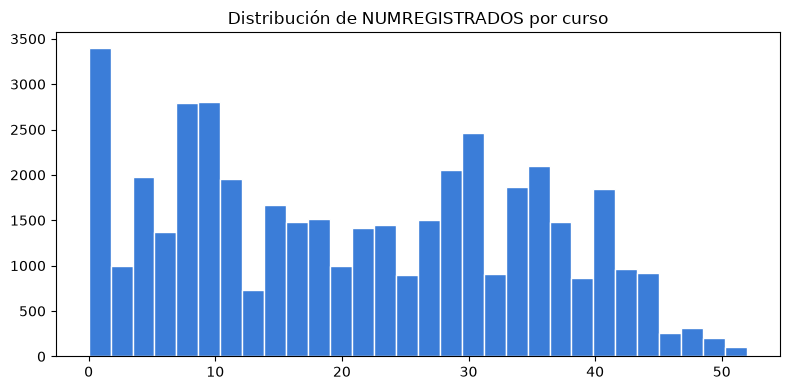

In [ ]:
pc.grafico_histograma(df['NUMREGISTRADOS'], 'Distribución de NUMREGISTRADOS por curso', bins=30)

**Unidades académicas con más carga docente registrada**.

<Axes: title={'center': 'Top 10 unidades académicas por N.º de cursos'}, ylabel='NOMBREUNIDAD'>

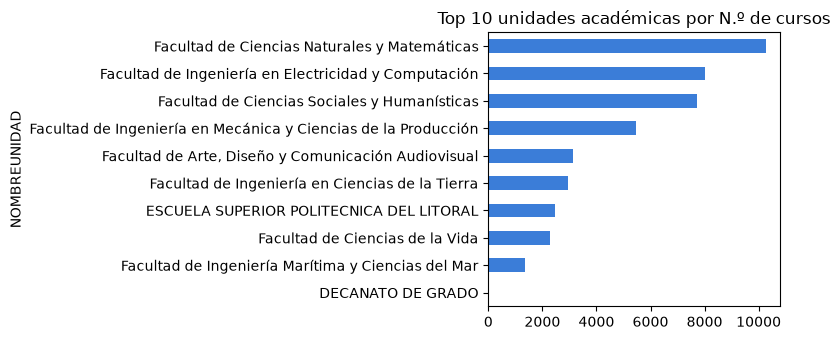

In [ ]:
pc.grafico_barras(df['NOMBREUNIDAD'], 'Top 10 unidades académicas por N.º de cursos', top=10)

## 7. Verificación final

In [ ]:
pc.resumen(df, 'carga_academica_disponible (procesado)')
df.head()

--- Resumen carga_academica_disponible (procesado) ---
Dimensiones: 43701 filas x 32 columnas
Filas duplicadas: 0
Sin columnas con valores nulos.


,IDCPLCAMBIOSCURSO,HORASTEORICAS,HORASPRACTICAS,IDPERSONA,NUMEROIDENTIFICACION,TIPOIDENTIFICACION,NOMDOCENTE,IDCURSO,PORC,ANIO,TERM,NUMREGISTRADOS,PARALELO,CAPACIDAD,CUPOPLANIFICADO,IDUNIDAD,CODUNIDAD,NOMBREUNIDAD,IDMATERIA,CODIGOMATERIA,NOMMATERIA,NUMCREDITOS,TIPOCURSO,NUMHORASTEORICAS,NUMHORASPRACTICAS,IDPERIODO,NUMHORASCA,VALORNUMEXAM,FECHA_INICIO,FECHA_FIN,TIPOPROFESOR,TOTALHORAS
0,65429,2,1,1298,0911582120,CED,LAVAYEN CARDOSO LUIS ENRIQUE,171804,25.0,2024,1S,0,101,1,17,15266,ESPL,ESCUELA SUPERIOR POLITECNICA DEL LITORAL,7879,IDIT3003,INGLÉS TÉCNICO I,0.0,G,2,1,598,3,2,2024-06-24,2024-06-30,C,0.38
1,89609,3,1,4714,0923667927,CED,AVENDAÑO SUDARIO ALLAN ROBERTO,182090,100.0,2026,1S,30,101,30,35,15004,FIEC,Facultad de Ingeniería en Electricidad y Compu...,6822,SOFG1006,DESARROLLO DE APLICACIONES WEB Y MÓVILES,0.0,G,3,1,605,4,6,2026-05-13,2026-05-15,T,0.62
2,89613,3,1,4714,0923667927,CED,AVENDAÑO SUDARIO ALLAN ROBERTO,182110,100.0,2026,1S,22,103,30,35,15004,FIEC,Facultad de Ingeniería en Electricidad y Compu...,6822,SOFG1006,DESARROLLO DE APLICACIONES WEB Y MÓVILES,0.0,G,3,1,605,4,6,2026-05-13,2026-05-15,T,0.62
3,65425,2,1,1298,0911582120,CED,LAVAYEN CARDOSO LUIS ENRIQUE,171803,25.0,2024,1S,15,1,16,16,15266,ESPL,ESCUELA SUPERIOR POLITECNICA DEL LITORAL,7879,IDIT3003,INGLÉS TÉCNICO I,0.0,P,2,1,598,3,2,2024-06-24,2024-06-30,C,0.77
4,16805,3,0,59234,0928567783,CED,VALENCIA ERAZO LUZ MARÍA,138539,15.0,2020,1S,14,1,20,20,15300,FCV,Facultad de Ciencias de la Vida,6955,NUTG2036,NUTRICIÓN EN EL CICLO DE LA VIDA I,0.0,P,3,0,574,3,6,2020-05-25,2020-06-05,C,1.34


## 8. Guardado en data/processed

In [ ]:
pc.guardar_procesado(df, 'carga_academica_disponible.csv')

Guardado: D:\Proyecto_Tesis\data\processed\carga_academica_disponible.csv (43701 filas x 32 columnas)


WindowsPath('D:/Proyecto_Tesis/data/processed/carga_academica_disponible.csv')